In [3]:
# Step 0 — Optional installs + version check
!pip -q install xgboost==2.1.1

import sys, pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt
import sklearn, xgboost as xgb

print("Python:", sys.version)
print("pandas:", pd.__version__)
print("numpy :", np.__version__)
print("sklearn:", sklearn.__version__)
print("xgboost:", xgb.__version__)

sns.set_theme()


Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
pandas: 2.2.2
numpy : 2.0.2
sklearn: 1.6.1
xgboost: 2.1.1


In [4]:
# Step 1 — Upload datasets interactively
from google.colab import files
import pandas as pd

print("➡️ Please upload pokemon.csv and combats.csv from your computer")
uploaded = files.upload()

# Get file names
fnames = list(uploaded.keys())
print("✅ Files uploaded:", fnames)

# Utility function to load based on likely file name
def load_csv_guess(name_candidates):
    for cand in name_candidates:
        if cand in uploaded:
            return pd.read_csv(cand)
    for k in uploaded:
        if k.lower().endswith(".csv"):
            return pd.read_csv(k)
    raise FileNotFoundError("Expected CSV not found among uploaded files.")

# Load data
pokemon = load_csv_guess(["pokemon.csv"])
combats = load_csv_guess(["combats.csv"])

print("pokemon shape:", pokemon.shape)
print("combats shape:", combats.shape)
pokemon.head(), combats.head()


➡️ Please upload pokemon.csv and combats.csv from your computer


Saving combats.csv to combats.csv
Saving pokemon.csv to pokemon.csv
Saving tests.csv to tests.csv
✅ Files uploaded: ['combats.csv', 'pokemon.csv', 'tests.csv']
pokemon shape: (800, 12)
combats shape: (50000, 3)


(   #           Name Type 1  Type 2  HP  Attack  Defense  Sp. Atk  Sp. Def  \
 0  1      Bulbasaur  Grass  Poison  45      49       49       65       65   
 1  2        Ivysaur  Grass  Poison  60      62       63       80       80   
 2  3       Venusaur  Grass  Poison  80      82       83      100      100   
 3  4  Mega Venusaur  Grass  Poison  80     100      123      122      120   
 4  5     Charmander   Fire     NaN  39      52       43       60       50   
 
    Speed  Generation  Legendary  
 0     45           1      False  
 1     60           1      False  
 2     80           1      False  
 3     80           1      False  
 4     65           1      False  ,
    First_pokemon  Second_pokemon  Winner
 0            266             298     298
 1            702             701     701
 2            191             668     668
 3            237             683     683
 4            151             231     151)

In [5]:
import numpy as np

# Detect ID column (may be "#", "Number", or "id")
pokemon_cols = {c.lower().strip(): c for c in pokemon.columns}
id_col = None
for cand in ["#", "number", "id"]:
    if cand in pokemon_cols:
        id_col = pokemon_cols[cand]
        break

# Detect common column names
def col_or_none(*cands):
    for c in cands:
        if c.lower() in pokemon_cols:
            return pokemon_cols[c.lower()]
    return None

name_col   = col_or_none("name")
type1_col  = col_or_none("type 1", "type1")
type2_col  = col_or_none("type 2", "type2")
legend_col = col_or_none("legendary", "is_legendary")
hp_col     = col_or_none("hp")
atk_col    = col_or_none("attack")
def_col    = col_or_none("defense")
spatk_col  = col_or_none("sp. atk", "sp_atk", "special attack")
spdef_col  = col_or_none("sp. def", "sp_def", "special defense")
spd_col    = col_or_none("speed")

# Fix: Missing Name for Pokémon #62 → "Primeape"
if name_col is not None:
    mask_62 = (pokemon[id_col] == 62) & (pokemon[name_col].isna())
    if mask_62.any():
        pokemon.loc[mask_62, name_col] = "Primeape"
        print("🔧 Fixed missing name for Pokémon #62 (Primeape)")

# Handle missing Type 2 by filling "None"
if type2_col is not None:
    pokemon[type2_col] = pokemon[type2_col].fillna("None")

# Compute win percentage from combats.csv
comb_cols = {c.lower().strip(): c for c in combats.columns}
first_col, second_col, winner_col = None, None, None
for c in comb_cols:
    if "first" in c: first_col = comb_cols[c]
    if "second" in c: second_col = comb_cols[c]
    if "winner" in c: winner_col = comb_cols[c]

# Count number of battles per Pokémon
appear = pd.concat([
    combats[first_col].rename("poke_id"),
    combats[second_col].rename("poke_id")
], axis=0).to_frame()
battles_per_poke = appear.groupby("poke_id").size().rename("battles")

# Count wins per Pokémon
wins_per_poke = combats[winner_col].value_counts().rename("wins")

# Merge and compute win percentage
wp = pd.concat([battles_per_poke, wins_per_poke], axis=1).fillna(0.0)
wp["win_pct"] = (wp["wins"] / wp["battles"]).astype(float)

# Merge with Pokémon data
pokemon_merged = pokemon.merge(wp, left_on=id_col, right_index=True, how="left")
pokemon_merged[["battles", "wins", "win_pct"]] = pokemon_merged[["battles", "wins", "win_pct"]].fillna(0.0)

pokemon_merged[[id_col, name_col, type1_col, type2_col, "battles", "wins", "win_pct"]].head()


,#,Name,Type 1,Type 2,battles,wins,win_pct
0,1,Bulbasaur,Grass,Poison,133.0,37.0,0.278195
1,2,Ivysaur,Grass,Poison,121.0,46.0,0.380165
2,3,Venusaur,Grass,Poison,132.0,89.0,0.674242
3,4,Mega Venusaur,Grass,Poison,125.0,70.0,0.560000
4,5,Charmander,Fire,None,112.0,55.0,0.491071


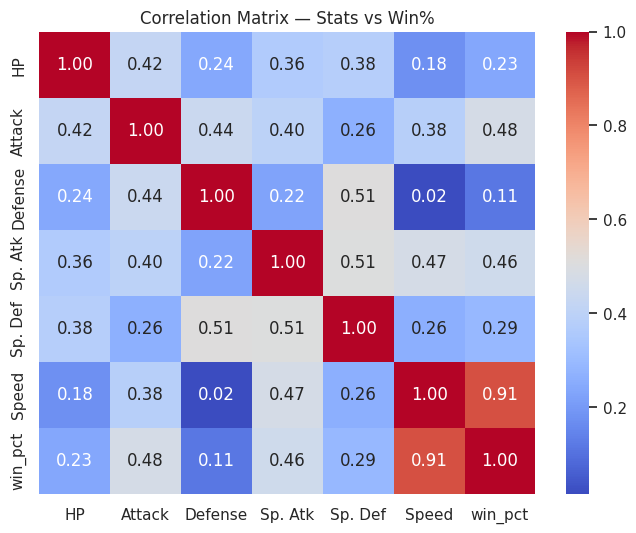

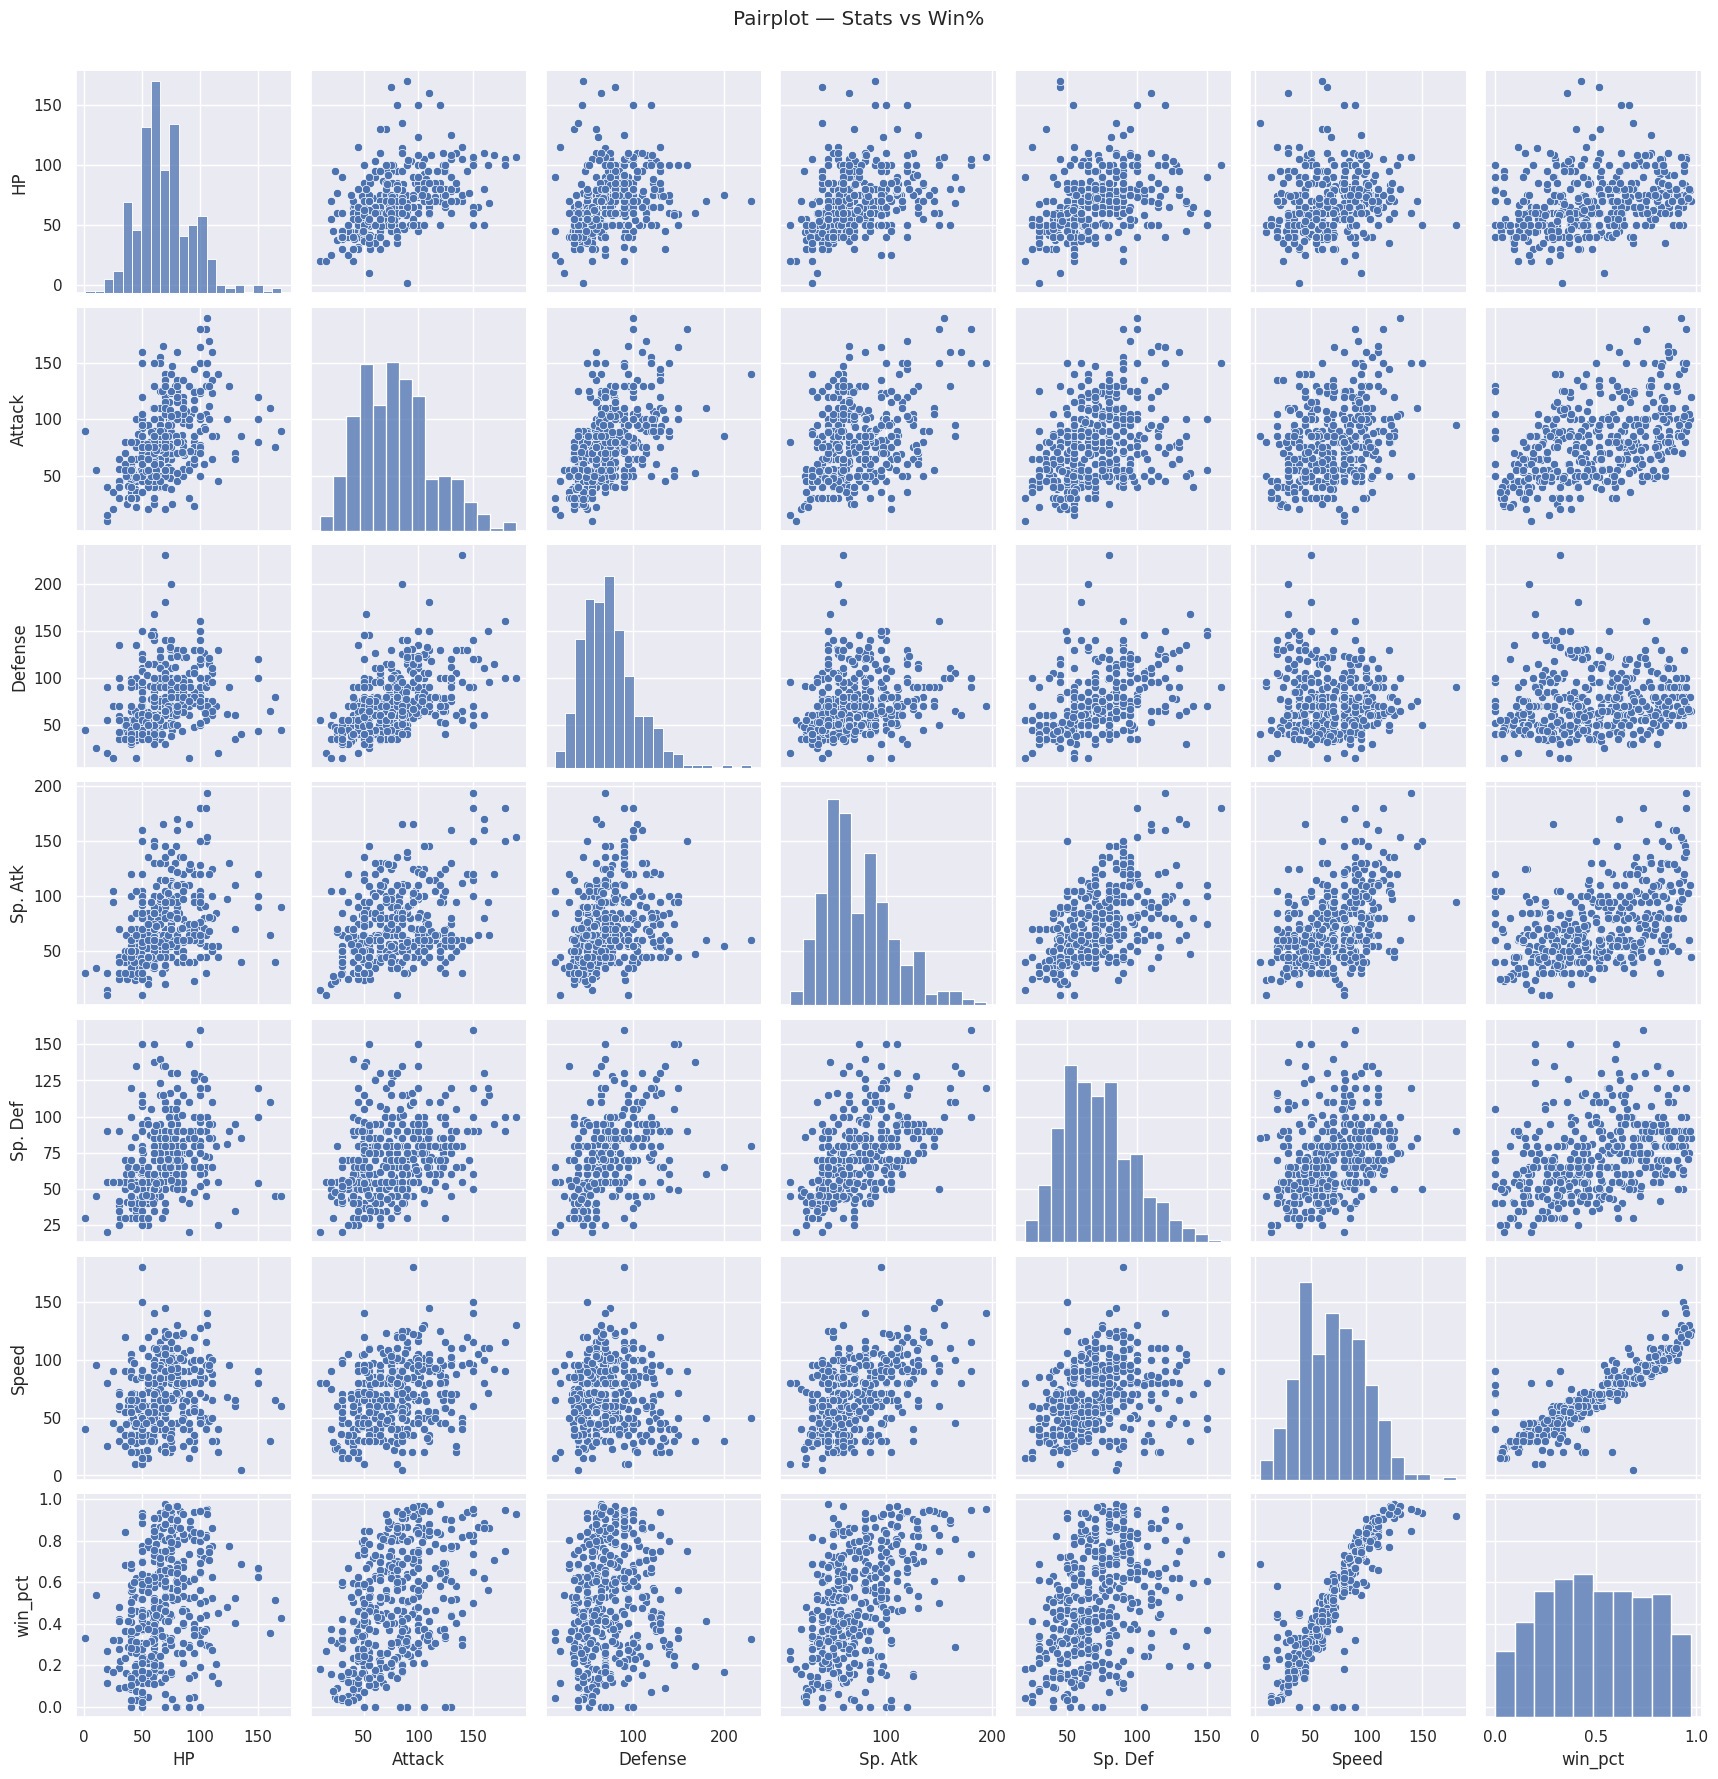

,#,Name,Type 1,Type 2,battles,wins,win_pct,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
154,155,Mega Aerodactyl,Rock,Flying,129.0,127.0,0.984496,80,135,85,70,95,150
512,513,Weavile,Dark,Ice,119.0,116.0,0.974790,70,120,65,45,85,125
703,704,Tornadus Therian Forme,Flying,None,125.0,121.0,0.968000,79,100,80,110,90,121
19,20,Mega Beedrill,Bug,Poison,119.0,115.0,0.966387,65,150,40,15,80,145
153,154,Aerodactyl,Rock,Flying,141.0,136.0,0.964539,80,105,65,60,75,130
476,477,Mega Lopunny,Normal,Fighting,129.0,124.0,0.961240,65,136,94,54,96,135
726,727,Greninja,Water,Dark,127.0,122.0,0.960630,72,95,67,103,71,122
716,717,Meloetta Pirouette Forme,Normal,Fighting,123.0,118.0,0.959350,100,128,90,77,77,128
164,165,Mega Mewtwo Y,Psychic,None,125.0,119.0,0.952000,106,150,70,194,120,140
349,350,Mega Sharpedo,Water,Dark,120.0,114.0,0.950000,70,140,70,110,65,105


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns for correlation
stat_cols = [c for c in [hp_col, atk_col, def_col, spatk_col, spdef_col, spd_col] if c is not None]
num_df = pokemon_merged[stat_cols + ["win_pct"]].copy()

# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(num_df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix — Stats vs Win%")
plt.show()

# Pairplot (sample 400 Pokémon for speed)
sample_pp = pokemon_merged.sample(n=min(400, len(pokemon_merged)), random_state=42)
sns.pairplot(sample_pp[stat_cols + ["win_pct"]], diag_kind="hist")
plt.suptitle("Pairplot — Stats vs Win%", y=1.02)
plt.show()

# Display Top 10 Pokémon by win percentage
top10 = pokemon_merged.sort_values("win_pct", ascending=False).head(10)
disp_cols = [c for c in [id_col, name_col, type1_col, type2_col, "battles", "wins", "win_pct"] + stat_cols if c is not None]
top10[disp_cols]


In [7]:
from sklearn.model_selection import train_test_split

# Select feature and target columns
feature_cols = [c for c in stat_cols if c is not None] + ["battles"]
target_col = "win_pct"

cat_cols = []
if type1_col is not None: cat_cols.append(type1_col)
if type2_col is not None: cat_cols.append(type2_col)
if legend_col is not None: cat_cols.append(legend_col)

X = pokemon_merged[feature_cols + cat_cols].copy()
y = pokemon_merged[target_col].copy()

# Ensure categorical features are strings
for c in cat_cols:
    X[c] = X[c].astype(str)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train.shape, X_test.shape, y_train.shape


((640, 10), (160, 10), (640,))

In [11]:
# Step 5 (FIXED) — Train and evaluate models without Pipeline for XGBoost
# This avoids the sklearn 1.5 ↔︎ xgboost 2.x __sklearn_tags__ issue.

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import pandas as pd
import numpy as np

# --- Preprocessing: fit once on train, transform to arrays ---
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, feature_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

# Fit the preprocessor on training data only
X_train_proc = preprocess.fit_transform(X_train)
X_test_proc  = preprocess.transform(X_test)

# --- Define models (no sklearn Pipeline wrappers) ---
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(
        n_estimators=400, random_state=42, n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        n_estimators=600, max_depth=6, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9, objective="reg:squarederror",
        random_state=42, n_jobs=-1
    )
}

results = []
preds = {}  # keep predictions if you want to analyze later

for name, model in models.items():
    try:
        # Fit on preprocessed arrays
        model.fit(X_train_proc, y_train)
        y_pred = model.predict(X_test_proc)
        mae = mean_absolute_error(y_test, y_pred)
        results.append((name, mae))
        preds[name] = y_pred
        print(f"{name} — MAE: {mae:.4f}")
    except Exception as e:
        # If any model fails (e.g., environment issues), report and skip
        print(f"{name} — skipped due to: {e}")

score_df = pd.DataFrame(results, columns=["Model","MAE"]).sort_values("MAE")
score_df


LinearRegression — MAE: 0.0609
RandomForest — MAE: 0.0406
XGBoost — MAE: 0.0421


,Model,MAE
1,RandomForest,0.040591
2,XGBoost,0.042077
0,LinearRegression,0.060859


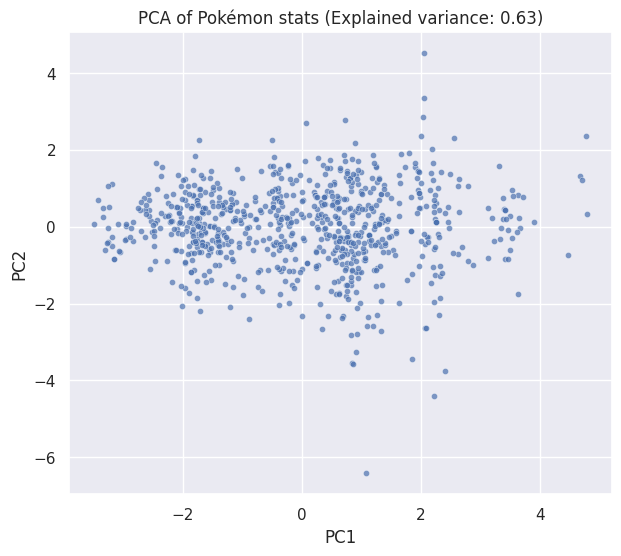

In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Perform PCA only on numeric stats
stats_only = pokemon_merged[stat_cols].dropna()
scaled = StandardScaler().fit_transform(stats_only)
pca = PCA(n_components=2, random_state=42)
pc = pca.fit_transform(scaled)

pc_df = pd.DataFrame(pc, columns=["PC1", "PC2"])
plt.figure(figsize=(7,6))
sns.scatterplot(x="PC1", y="PC2", data=pc_df, s=20, alpha=0.7)
plt.title(f"PCA of Pokémon stats (Explained variance: {pca.explained_variance_ratio_.sum():.2f})")
plt.show()


In [13]:
# Export cleaned dataset with win percentage
pokemon_merged.to_csv("pokemon_enriched_with_win_pct.csv", index=False)
print("💾 Exported: pokemon_enriched_with_win_pct.csv")

# Export top 10 leaderboard
top10 = pokemon_merged.sort_values("win_pct", ascending=False).head(10)
top10.to_csv("pokemon_top10_winpct.csv", index=False)
print("💾 Exported: pokemon_top10_winpct.csv")


💾 Exported: pokemon_enriched_with_win_pct.csv
💾 Exported: pokemon_top10_winpct.csv
